# AH-PC — 01 Data Pipeline
> **Project:** Adaptive Horizon Predictive Coding for EEG-based Emotion Recognition  
> **Dataset:** SEED-V Differential Entropy (DE) features  
> **Author:** Divya Bharathi Kannappan

**What this notebook does:**
1. Loads all 16 subject `.npz` files
2. Reshapes each trial to `(T, 62, 5)` — T segments × 62 channels × 5 frequency bands
3. Builds multi-horizon prediction pairs for k ∈ {1, 2, 4, 8}: for every valid anchor `segment[i]`, stores all four future targets `segment[i+k]` plus the emotion label
4. Saves per-subject pair files as `.pkl` in `src/data/processed/`
5. Prints summary statistics: pairs per subject, per horizon, class distribution

## 0. Imports & Constants

In [1]:
import os
import glob
import pickle
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR      = '/workspaces/AH-PC/src/data/EEG_DE_features'
PROCESSED_DIR = '/workspaces/AH-PC/src/data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────────────
N_CHANNELS     = 62
N_BANDS        = 5
HORIZONS       = [1, 2, 4, 8]          # prediction steps ahead
MAX_HORIZON    = max(HORIZONS)          # = 8; anchor must have i + 8 < T
EMOTION_NAMES  = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']
EMOTION_COLORS = ['#E07B54', '#7B68EE', '#5B9BD5', '#A9A9A9', '#70B87E']

print('Imports OK')
print(f'Raw data  : {DATA_DIR}')
print(f'Output dir: {PROCESSED_DIR}')
print(f'Horizons  : {HORIZONS}')

Imports OK
Raw data  : /workspaces/AH-PC/src/data/EEG_DE_features
Output dir: /workspaces/AH-PC/src/data/processed
Horizons  : [1, 2, 4, 8]


## 1. Load Raw .npz Files

Each `.npz` stores a pickled Python dict `{trial_id: flat_array}` for both `data` and `label`.  
Trials are indexed 0–44 (45 trials = 3 sessions × 15 clips).  
All segments within a trial share the same emotion label (`label[trial_id][0]`).

In [2]:
npz_files = sorted(
    glob.glob(f'{DATA_DIR}/*.npz'),
    key=lambda p: int(os.path.basename(p).split('_')[0])
)
print(f'Found {len(npz_files)} subject files:')
for f in npz_files:
    print(f'  {os.path.basename(f)}')

# ── Load into memory ──────────────────────────────────────────────────────────
all_subjects = {}

for npz_path in npz_files:
    sid = int(os.path.basename(npz_path).split('_')[0])
    with np.load(npz_path, allow_pickle=True) as npz:
        raw_data   = pickle.loads(npz['data'].tobytes())
        raw_labels = pickle.loads(npz['label'].tobytes())
    all_subjects[sid] = {'data': raw_data, 'labels': raw_labels}

print(f'\nLoaded {len(all_subjects)} subjects: {sorted(all_subjects.keys())}')

# ── Quick sanity check on subject 1 ──────────────────────────────────────────
sid0  = sorted(all_subjects.keys())[0]
tid0  = sorted(all_subjects[sid0]['data'].keys())[0]
arr0  = all_subjects[sid0]['data'][tid0]
segs0 = arr0.reshape(-1, N_CHANNELS, N_BANDS)
print(f'\nSubject {sid0}, Trial {tid0}:')
print(f'  Raw flat shape : {arr0.shape}')
print(f'  Reshaped (T,62,5): {segs0.shape}')
print(f'  Emotion label  : {EMOTION_NAMES[int(all_subjects[sid0]["labels"][tid0][0])]}'
      f' ({int(all_subjects[sid0]["labels"][tid0][0])}')

Found 16 subject files:
  1_123.npz
  2_123.npz
  3_123.npz
  4_123.npz
  5_123.npz
  6_123.npz
  7_123.npz
  8_123.npz
  9_123.npz
  10_123.npz
  11_123.npz
  12_123.npz
  13_123.npz
  14_123.npz
  15_123.npz
  16_123.npz



Loaded 16 subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

Subject 1, Trial 0:
  Raw flat shape : (18, 310)
  Reshaped (T,62,5): (18, 62, 5)
  Emotion label  : Happy (4


## 2. Build Multi-Horizon Prediction Pairs

### Pair construction rule
For a trial with T segments, a pair is created at index `i` **only when** `i + MAX_HORIZON < T`  
(i.e., all four future targets exist simultaneously). This guarantees every pair has a complete  
set of targets for k ∈ {1, 2, 4, 8}.

```
pair = {
    'anchor'  : segment[i],          # shape (62, 5)
    'targets' : {1: segment[i+1],    # shape (62, 5) each
                 2: segment[i+2],
                 4: segment[i+4],
                 8: segment[i+8]},
    'label'   : emotion_int,         # 0–4
    'subject' : subject_id,
    'trial'   : trial_id,
    'seg_idx' : i,
}
```

> **Why require all horizons present?**  
> The AH-PC Horizon Attention Module compares losses across all k simultaneously. A partial pair  
> would produce an undefined loss for the missing horizons.

In [3]:
def build_pairs_for_subject(subject_dict, sid):
    """Return a list of pair dicts for one subject."""
    pairs = []
    for tid in sorted(subject_dict['data'].keys()):
        flat_arr = subject_dict['data'][tid]
        labels   = subject_dict['labels'][tid]      # shape (T,) — same label per segment
        segs     = flat_arr.reshape(-1, N_CHANNELS, N_BANDS)   # (T, 62, 5)
        T        = len(segs)

        # Only create pairs where i + MAX_HORIZON < T
        for i in range(T - MAX_HORIZON):
            pair = {
                'anchor' : segs[i].copy(),
                'targets': {k: segs[i + k].copy() for k in HORIZONS},
                'label'  : int(labels[i]),
                'subject': sid,
                'trial'  : tid,
                'seg_idx': i,
            }
            pairs.append(pair)
    return pairs


# ── Build pairs for all subjects ──────────────────────────────────────────────
all_pairs = {}   # {sid: [pair, ...]}

for sid in sorted(all_subjects.keys()):
    pairs = build_pairs_for_subject(all_subjects[sid], sid)
    all_pairs[sid] = pairs
    print(f'Subject {sid:2d}: {len(pairs):5,} pairs  '
          f'({len(all_subjects[sid]["data"])} trials)')

total_pairs = sum(len(v) for v in all_pairs.values())
print(f'\nTotal pairs across all subjects: {total_pairs:,}')

# ── Inspect one pair ──────────────────────────────────────────────────────────
sample_pair = all_pairs[1][0]
print(f'\nSample pair (Subject 1, pair 0):')
print(f'  anchor shape     : {sample_pair["anchor"].shape}')
print(f'  target shapes    : { {k: v.shape for k, v in sample_pair["targets"].items()} }')
print(f'  label            : {sample_pair["label"]} ({EMOTION_NAMES[sample_pair["label"]]})')
print(f'  trial / seg_idx  : {sample_pair["trial"]} / {sample_pair["seg_idx"]}')

Subject  1: 1,463 pairs  (45 trials)
Subject  2: 1,463 pairs  (45 trials)
Subject  3: 1,463 pairs  (45 trials)
Subject  4: 1,463 pairs  (45 trials)
Subject  5: 1,463 pairs  (45 trials)
Subject  6: 1,463 pairs  (45 trials)
Subject  7: 1,463 pairs  (45 trials)
Subject  8: 1,463 pairs  (45 trials)
Subject  9: 1,463 pairs  (45 trials)


Subject 10: 1,463 pairs  (45 trials)
Subject 11: 1,463 pairs  (45 trials)


Subject 12: 1,463 pairs  (45 trials)
Subject 13: 1,463 pairs  (45 trials)
Subject 14: 1,463 pairs  (45 trials)
Subject 15: 1,463 pairs  (45 trials)


Subject 16: 1,463 pairs  (45 trials)

Total pairs across all subjects: 23,408

Sample pair (Subject 1, pair 0):
  anchor shape     : (62, 5)
  target shapes    : {1: (62, 5), 2: (62, 5), 4: (62, 5), 8: (62, 5)}
  label            : 4 (Happy)
  trial / seg_idx  : 0 / 0


## 3. Save Per-Subject Pair Files

Each subject's pairs are saved as `subject_{sid:02d}_pairs.pkl` in `src/data/processed/`.  
Loading a file gives back the exact list of pair dicts.

In [4]:
saved_files = []

for sid, pairs in all_pairs.items():
    out_path = os.path.join(PROCESSED_DIR, f'subject_{sid:02d}_pairs.pkl')
    with open(out_path, 'wb') as f:
        pickle.dump(pairs, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = os.path.getsize(out_path) / 1e6
    print(f'Saved subject {sid:2d}: {out_path}  ({size_mb:.1f} MB)')
    saved_files.append(out_path)

print(f'\nAll {len(saved_files)} subject files written to: {PROCESSED_DIR}')

# ── Round-trip verification on subject 1 ─────────────────────────────────────
with open(saved_files[0], 'rb') as f:
    loaded = pickle.load(f)

assert len(loaded) == len(all_pairs[1]), 'Pair count mismatch after reload'
np.testing.assert_array_equal(loaded[0]['anchor'], all_pairs[1][0]['anchor'])
print(f'\nRound-trip check passed: {len(loaded)} pairs reloaded correctly from subject 1 file.')

Saved subject  1: /workspaces/AH-PC/src/data/processed/subject_01_pairs.pkl  (18.4 MB)


Saved subject  2: /workspaces/AH-PC/src/data/processed/subject_02_pairs.pkl  (18.4 MB)
Saved subject  3: /workspaces/AH-PC/src/data/processed/subject_03_pairs.pkl  (18.4 MB)


Saved subject  4: /workspaces/AH-PC/src/data/processed/subject_04_pairs.pkl  (18.4 MB)


Saved subject  5: /workspaces/AH-PC/src/data/processed/subject_05_pairs.pkl  (18.4 MB)
Saved subject  6: /workspaces/AH-PC/src/data/processed/subject_06_pairs.pkl  (18.4 MB)


Saved subject  7: /workspaces/AH-PC/src/data/processed/subject_07_pairs.pkl  (18.4 MB)
Saved subject  8: /workspaces/AH-PC/src/data/processed/subject_08_pairs.pkl  (18.4 MB)


...

Saved subject 11: /workspaces/AH-PC/src/data/processed/subject_11_pairs.pkl  (18.4 MB)


Saved subject 12: /workspaces/AH-PC/src/data/processed/subject_12_pairs.pkl  (18.4 MB)
Saved subject 13: /workspaces/AH-PC/src/data/processed/subject_13_pairs.pkl  (18.4 MB)


Saved subject 14: /workspaces/AH-PC/src/data/processed/subject_14_pairs.pkl  (18.4 MB)
Saved subject 15: /workspaces/AH-PC/src/data/processed/subject_15_pairs.pkl  (18.4 MB)


Saved subject 16: /workspaces/AH-PC/src/data/processed/subject_16_pairs.pkl  (18.4 MB)

All 16 subject files written to: /workspaces/AH-PC/src/data/processed



Round-trip check passed: 1463 pairs reloaded correctly from subject 1 file.


## 4. Summary Statistics

Reports:
- Total pairs per subject
- Pairs available per horizon (all equal by construction)
- Class distribution across all pairs

In [5]:
# ── Per-subject table ─────────────────────────────────────────────────────────
rows = []
for sid in sorted(all_pairs.keys()):
    pairs = all_pairs[sid]
    label_counts = defaultdict(int)
    for p in pairs:
        label_counts[p['label']] += 1
    row = {
        'Subject'  : sid,
        'N_Pairs'  : len(pairs),
        'N_Trials' : len(all_subjects[sid]['data']),
    }
    for e, ename in enumerate(EMOTION_NAMES):
        row[ename] = label_counts[e]
    rows.append(row)

df = pd.DataFrame(rows).set_index('Subject')

print('=' * 75)
print('  Per-Subject Pair Summary')
print('=' * 75)
print(df.to_string())
print('-' * 75)
print(f'Total pairs : {df["N_Pairs"].sum():,}')
print(f'Mean / subj : {df["N_Pairs"].mean():.1f}')
print(f'Std  / subj : {df["N_Pairs"].std():.1f}')

  Per-Subject Pair Summary
         N_Pairs  N_Trials  Disgust  Fear  Sad  Neutral  Happy
Subject                                                       
1           1463        45      234   301  404      295    229
2           1463        45      234   301  404      295    229
3           1463        45      234   301  404      295    229
4           1463        45      234   301  404      295    229
5           1463        45      234   301  404      295    229
6           1463        45      234   301  404      295    229
7           1463        45      234   301  404      295    229
8           1463        45      234   301  404      295    229
9           1463        45      234   301  404      295    229
10          1463        45      234   301  404      295    229
11          1463        45      234   301  404      295    229
12          1463        45      234   301  404      295    229
13          1463        45      234   301  404      295    229
14          1463        45  

In [6]:
# ── Per-horizon counts (equal by construction, confirms integrity) ────────────
print('=' * 45)
print('  Pairs available per horizon')
print('=' * 45)
print(f'{"Horizon k":>12}  {"Pairs":>10}  {"% of total":>10}')
print('-' * 45)

all_pairs_flat = [p for pairs in all_pairs.values() for p in pairs]
for k in HORIZONS:
    # Every pair has all horizons; count confirms structure
    count = sum(1 for p in all_pairs_flat if k in p['targets'])
    pct   = count / len(all_pairs_flat) * 100
    print(f'{k:>12}  {count:>10,}  {pct:>9.1f}%')

print('-' * 45)
print(f'Total unique anchors: {len(all_pairs_flat):,}')

  Pairs available per horizon
   Horizon k       Pairs  % of total
---------------------------------------------
           1      23,408      100.0%
           2      23,408      100.0%
           4      23,408      100.0%
           8      23,408      100.0%
---------------------------------------------
Total unique anchors: 23,408


In [7]:
# ── Global class distribution ─────────────────────────────────────────────────
label_counts_global = defaultdict(int)
for p in all_pairs_flat:
    label_counts_global[p['label']] += 1

print('=' * 45)
print('  Global Class Distribution (all pairs)')
print('=' * 45)
print(f'{"Emotion":>12}  {"Class":>6}  {"Pairs":>8}  {"Pct":>7}')
print('-' * 45)

total = len(all_pairs_flat)
for e, ename in enumerate(EMOTION_NAMES):
    cnt = label_counts_global[e]
    print(f'{ename:>12}  {e:>6}  {cnt:>8,}  {cnt/total*100:>6.1f}%')

print('-' * 45)
print(f'{"TOTAL":>12}         {total:>8,}  100.0%')

max_cnt = max(label_counts_global.values())
min_cnt = min(label_counts_global.values())
print(f'\nClass imbalance ratio (max/min): {max_cnt/min_cnt:.2f}x')
if max_cnt / min_cnt > 1.5:
    print('  → Recommend weighted CrossEntropyLoss at fine-tuning time.')
else:
    print('  → Classes are reasonably balanced; standard loss should suffice.')

  Global Class Distribution (all pairs)
     Emotion   Class     Pairs      Pct
---------------------------------------------
     Disgust       0     3,744    16.0%
        Fear       1     4,816    20.6%
         Sad       2     6,464    27.6%
     Neutral       3     4,720    20.2%
       Happy       4     3,664    15.7%
---------------------------------------------
       TOTAL           23,408  100.0%

Class imbalance ratio (max/min): 1.76x
  → Recommend weighted CrossEntropyLoss at fine-tuning time.


## 5. Visualisations

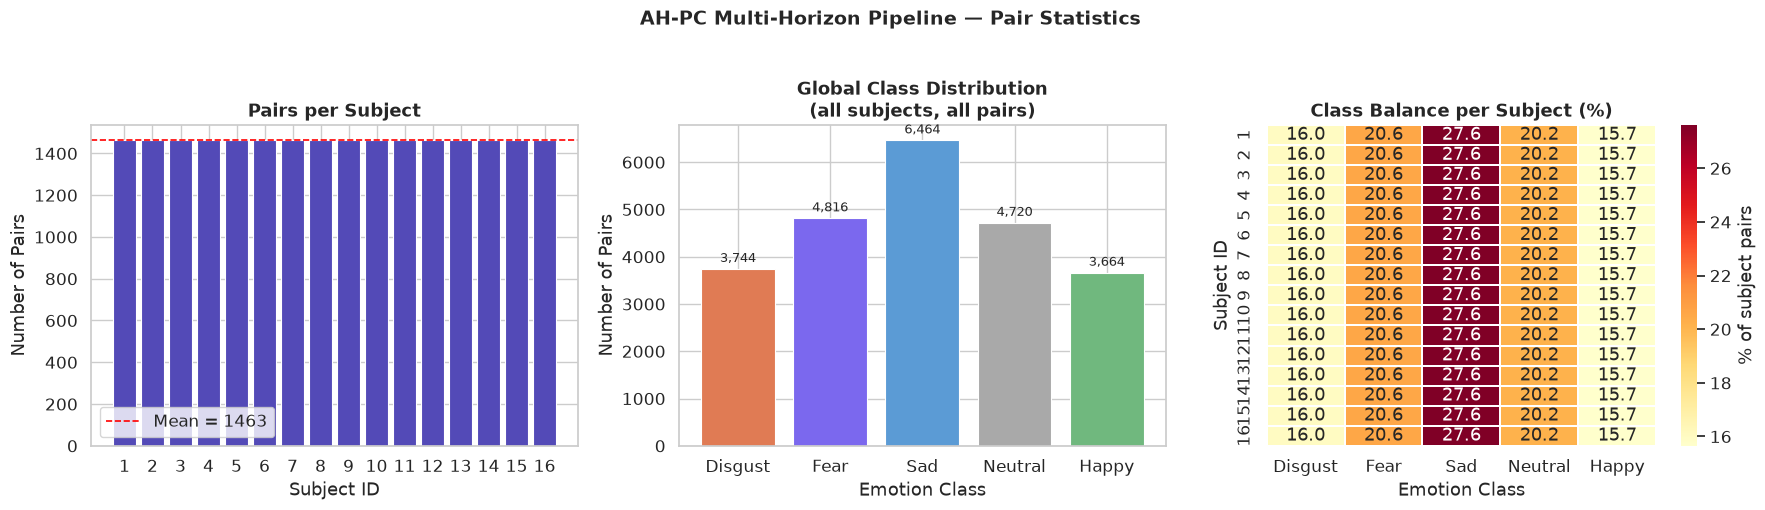

Saved → pair_statistics.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (a) Pairs per subject ─────────────────────────────────────────────────────
subj_ids   = df.index.tolist()
pair_counts = df['N_Pairs'].tolist()
axes[0].bar(subj_ids, pair_counts, color='#534AB7', edgecolor='white', linewidth=0.8)
axes[0].axhline(df['N_Pairs'].mean(), color='red', linestyle='--', linewidth=1.2,
                label=f'Mean = {df["N_Pairs"].mean():.0f}')
axes[0].set_title('Pairs per Subject', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Number of Pairs')
axes[0].set_xticks(subj_ids)
axes[0].legend()

# ── (b) Class distribution (global) ──────────────────────────────────────────
class_cnts = [label_counts_global[e] for e in range(5)]
bars = axes[1].bar(EMOTION_NAMES, class_cnts, color=EMOTION_COLORS,
                   edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, class_cnts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Global Class Distribution\n(all subjects, all pairs)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Emotion Class')
axes[1].set_ylabel('Number of Pairs')

# ── (c) Class balance per subject (heatmap) ───────────────────────────────────
balance_mat = df[EMOTION_NAMES].values.astype(float)
balance_pct = (balance_mat.T / balance_mat.sum(axis=1)).T * 100
sns.heatmap(balance_pct, ax=axes[2], annot=True, fmt='.1f',
            xticklabels=EMOTION_NAMES, yticklabels=subj_ids,
            cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': '% of subject pairs'})
axes[2].set_title('Class Balance per Subject (%)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Emotion Class')
axes[2].set_ylabel('Subject ID')

plt.suptitle('AH-PC Multi-Horizon Pipeline — Pair Statistics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/workspaces/AH-PC/src/notebooks/pair_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pair_statistics.png')

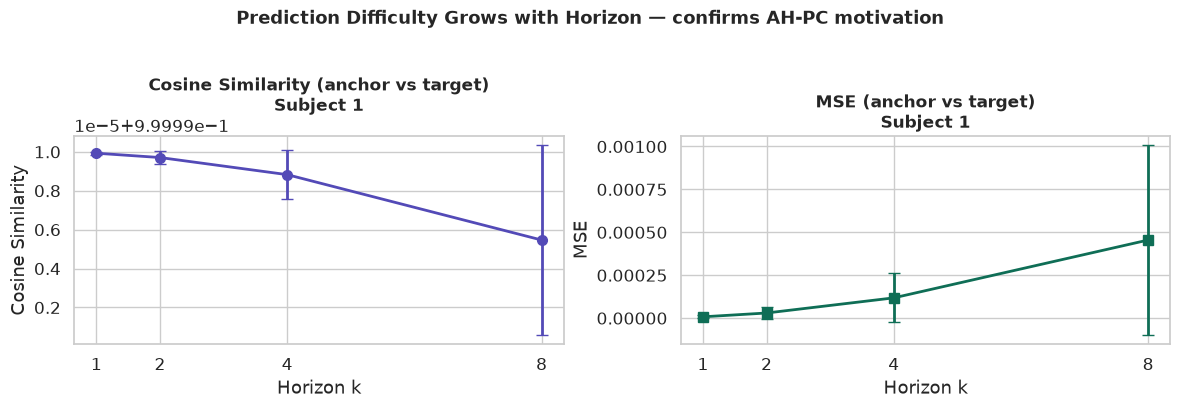

Saved → horizon_difficulty.png


In [9]:
# ── Anchor-target cosine similarity vs horizon (sanity check) ─────────────────
# Computed on subject 1 only to keep this cell fast
sample_sid   = 1
sample_pairs = all_pairs[sample_sid]

cos_by_k = {k: [] for k in HORIZONS}
mse_by_k = {k: [] for k in HORIZONS}

for p in sample_pairs:
    anc = p['anchor'].flatten()
    for k in HORIZONS:
        tgt  = p['targets'][k].flatten()
        cos  = np.dot(anc, tgt) / (np.linalg.norm(anc) * np.linalg.norm(tgt) + 1e-8)
        mse  = np.mean((anc - tgt) ** 2)
        cos_by_k[k].append(cos)
        mse_by_k[k].append(mse)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

means_cos = [np.mean(cos_by_k[k]) for k in HORIZONS]
stds_cos  = [np.std(cos_by_k[k])  for k in HORIZONS]
axes[0].errorbar(HORIZONS, means_cos, yerr=stds_cos,
                 marker='o', linewidth=2, markersize=7, color='#534AB7', capsize=4)
axes[0].set_title(f'Cosine Similarity (anchor vs target)\nSubject {sample_sid}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Horizon k')
axes[0].set_ylabel('Cosine Similarity')
axes[0].set_xticks(HORIZONS)

means_mse = [np.mean(mse_by_k[k]) for k in HORIZONS]
stds_mse  = [np.std(mse_by_k[k])  for k in HORIZONS]
axes[1].errorbar(HORIZONS, means_mse, yerr=stds_mse,
                 marker='s', linewidth=2, markersize=7, color='#0F6E56', capsize=4)
axes[1].set_title(f'MSE (anchor vs target)\nSubject {sample_sid}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Horizon k')
axes[1].set_ylabel('MSE')
axes[1].set_xticks(HORIZONS)

plt.suptitle('Prediction Difficulty Grows with Horizon — confirms AH-PC motivation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/workspaces/AH-PC/src/notebooks/horizon_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → horizon_difficulty.png')

## 6. How to Load the Processed Files

Quick reference snippet for downstream notebooks / training scripts.

In [10]:
# ── Example: load subject 3 and iterate pairs ─────────────────────────────────
example_path = os.path.join(PROCESSED_DIR, 'subject_03_pairs.pkl')
with open(example_path, 'rb') as f:
    subj3_pairs = pickle.load(f)

print(f'Subject 3 — {len(subj3_pairs)} pairs loaded')
print()
print('Usage pattern for training:')
print('  anchor  = pair["anchor"]        # np.ndarray (62, 5)')
print('  tgt_k1  = pair["targets"][1]    # np.ndarray (62, 5)')
print('  tgt_k2  = pair["targets"][2]    # np.ndarray (62, 5)')
print('  tgt_k4  = pair["targets"][4]    # np.ndarray (62, 5)')
print('  tgt_k8  = pair["targets"][8]    # np.ndarray (62, 5)')
print('  label   = pair["label"]         # int 0–4 (Disgust/Fear/Sad/Neutral/Happy)')

p = subj3_pairs[0]
print()
print(f'Pair 0: anchor={p["anchor"].shape}, '
      f'label={p["label"]} ({EMOTION_NAMES[p["label"]]}), '
      f'trial={p["trial"]}, seg={p["seg_idx"]}')

Subject 3 — 1463 pairs loaded

Usage pattern for training:
  anchor  = pair["anchor"]        # np.ndarray (62, 5)
  tgt_k1  = pair["targets"][1]    # np.ndarray (62, 5)
  tgt_k2  = pair["targets"][2]    # np.ndarray (62, 5)
  tgt_k4  = pair["targets"][4]    # np.ndarray (62, 5)
  tgt_k8  = pair["targets"][8]    # np.ndarray (62, 5)
  label   = pair["label"]         # int 0–4 (Disgust/Fear/Sad/Neutral/Happy)

Pair 0: anchor=(62, 5), label=4 (Happy), trial=0, seg=0


## 7. Final Summary

In [11]:
print('=' * 65)
print('  AH-PC Data Pipeline — Final Summary')
print('=' * 65)
print(f'  Subjects processed    : {len(all_pairs)}')
print(f'  Horizons per pair     : {HORIZONS}')
print(f'  Total pairs (all subj): {total:,}')
print(f'  Pairs per subject     : {total // len(all_pairs):,}  (identical across subjects)')
print()
print('  Class distribution:')
for e, ename in enumerate(EMOTION_NAMES):
    cnt = label_counts_global[e]
    bar = '█' * int(cnt / total * 40)
    print(f'    {ename:>8} ({e}): {cnt:>6,}  {cnt/total*100:5.1f}%  {bar}')
print()
print(f'  Output directory: {PROCESSED_DIR}')
print(f'  Files written   : {len(saved_files)}')
for f in saved_files:
    size_kb = os.path.getsize(f) / 1e3
    print(f'    {os.path.basename(f):30s}  {size_kb:7.1f} KB')
print('=' * 65)

  AH-PC Data Pipeline — Final Summary
  Subjects processed    : 16
  Horizons per pair     : [1, 2, 4, 8]
  Total pairs (all subj): 23,408
  Pairs per subject     : 1,463  (identical across subjects)

  Class distribution:
     Disgust (0):  3,744   16.0%  ██████
        Fear (1):  4,816   20.6%  ████████
         Sad (2):  6,464   27.6%  ███████████
     Neutral (3):  4,720   20.2%  ████████
       Happy (4):  3,664   15.7%  ██████

  Output directory: /workspaces/AH-PC/src/data/processed
  Files written   : 16
    subject_01_pairs.pkl            18394.0 KB
    subject_02_pairs.pkl            18394.0 KB
    subject_03_pairs.pkl            18394.0 KB
    subject_04_pairs.pkl            18394.0 KB
    subject_05_pairs.pkl            18394.0 KB
    subject_06_pairs.pkl            18394.0 KB
    subject_07_pairs.pkl            18394.0 KB
    subject_08_pairs.pkl            18394.0 KB
    subject_09_pairs.pkl            18394.0 KB
    subject_10_pairs.pkl            18394.0 KB
    subject_